In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data

In [20]:
train_data = pd.read_csv("data/prices_train.csv")
test_data = pd.read_csv("data/prices_test.csv")

### EDA

In [25]:
train_data.info()
train_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Unnamed: 0                              331 non-null    int64  
 1   X1 transaction date                     331 non-null    float64
 2   X2 house age                            323 non-null    float64
 3   X3 distance to the nearest MRT station  324 non-null    float64
 4   X4 number of convenience stores         317 non-null    float64
 5   X5 latitude                             331 non-null    float64
 6   X6 longitude                            331 non-null    float64
 7   Y house price of unit area              331 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 20.8 KB


,Unnamed: 0,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,0,2013.083,34.0,157.6052,7.0,24.96628,121.54196,39.1
1,1,2013.500,13.3,561.9845,5.0,24.98746,121.54391,54.8
2,2,2012.917,13.7,1236.5640,1.0,24.97694,121.55391,30.6
3,3,2013.500,8.5,104.8101,5.0,24.96674,121.54067,55.5
4,4,2013.500,13.2,1164.8380,NaN,24.99156,121.53406,34.3


In [22]:
train_data.describe()

,Unnamed: 0,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,331.000000,331.000000,323.000000,324.000000,317.000000,331.000000,331.000000,331.000000
mean,165.000000,2013.140994,17.937461,1102.361277,4.072555,24.969130,121.533612,38.293958
std,95.695698,0.281801,11.396095,1307.975099,2.938898,0.012901,0.015444,13.766246
min,0.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,82.500000,2012.917000,9.800000,289.324800,1.000000,24.962990,121.529665,28.550000
50%,165.000000,2013.083000,15.900000,492.231300,4.000000,24.972130,121.539130,38.800000
75%,247.500000,2013.417000,29.200000,1414.837000,6.000000,24.978440,121.543385,46.600000
max,330.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'X1 transaction date'}>,
        <Axes: title={'center': 'X2 house age'}>],
       [<Axes: title={'center': 'X3 distance to the nearest MRT station'}>,
        <Axes: title={'center': 'X4 number of convenience stores'}>,
        <Axes: title={'center': 'X5 latitude'}>],
       [<Axes: title={'center': 'X6 longitude'}>,
        <Axes: title={'center': 'Y house price of unit area'}>, <Axes: >]],
      dtype=object)

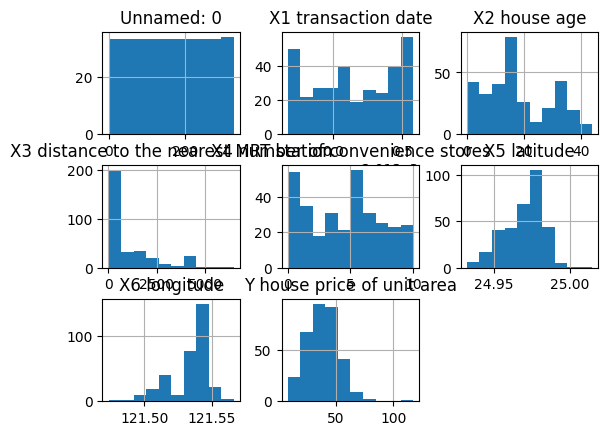

In [23]:
train_data.hist()

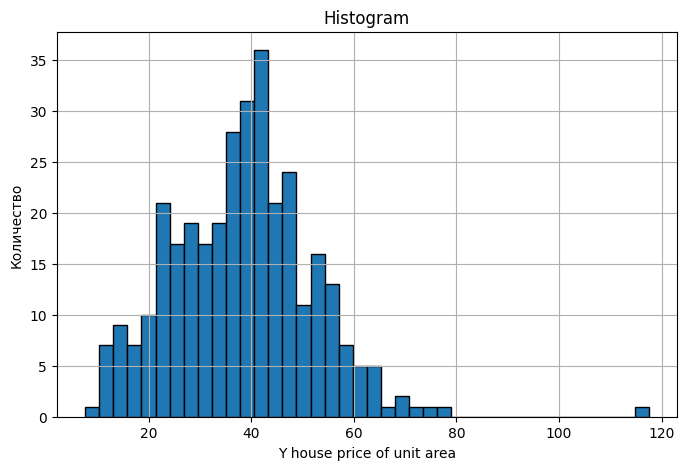

In [27]:
plt.figure(figsize=(8, 5))
train_data["Y house price of unit area"].hist(bins=40, edgecolor="black")
plt.title("Histogram")
plt.xlabel("Y house price of unit area")
plt.ylabel("Количество")
plt.show()

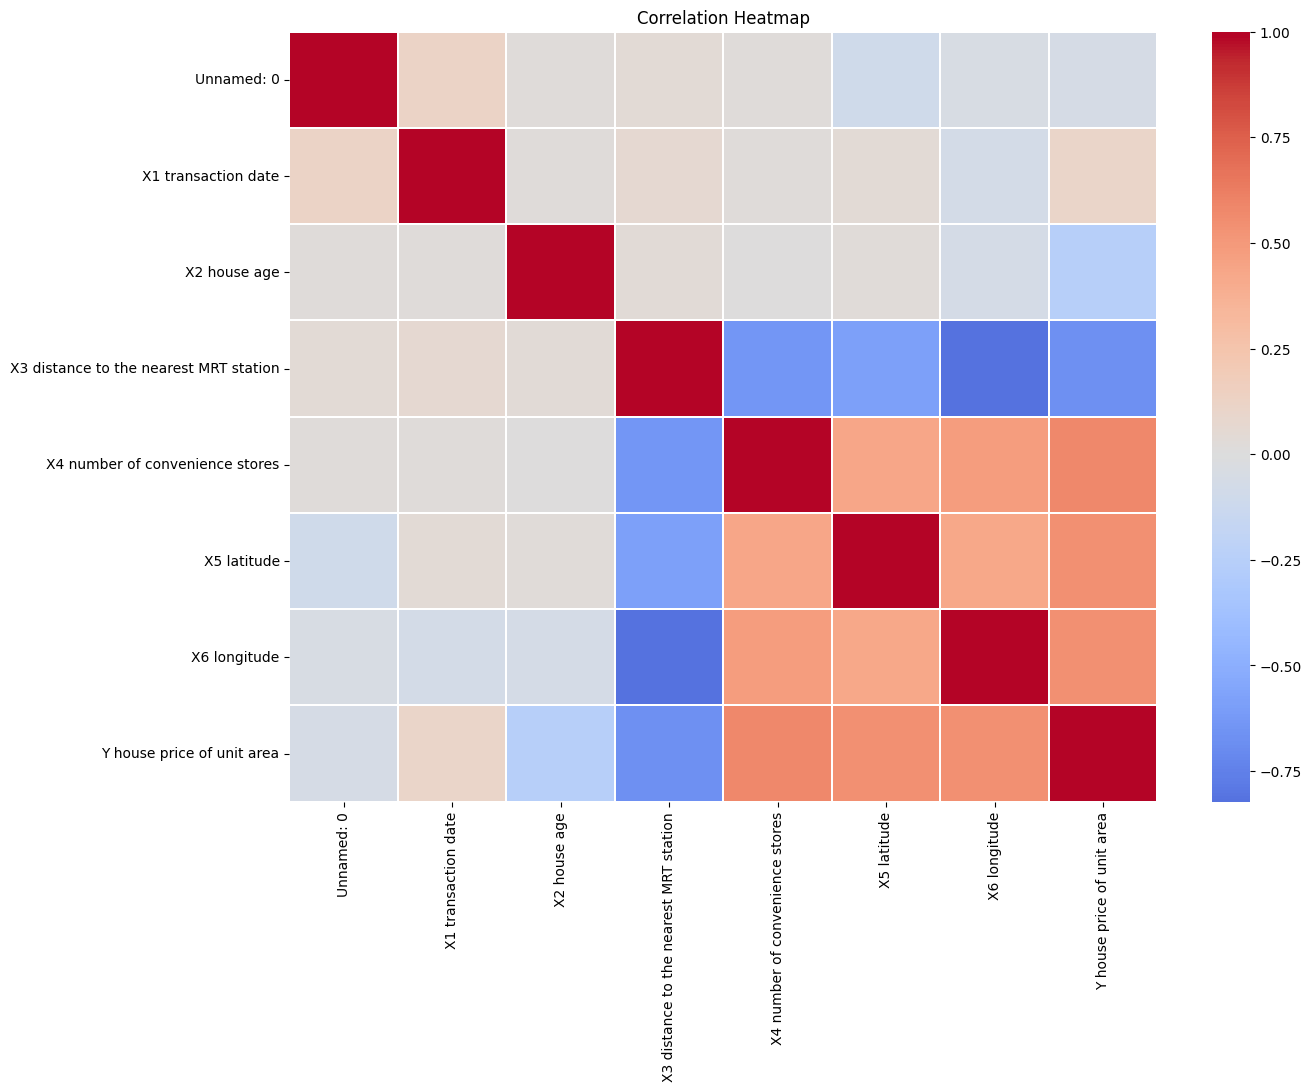

In [30]:
numeric_data = train_data.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()

### Fill NaNs

In [40]:
# 1) Сколько пропусков в каждом столбце
missing_count = train_data.isna().sum()
missing_count


Unnamed: 0                                 0
X1 transaction date                        0
X2 house age                               8
X3 distance to the nearest MRT station     7
X4 number of convenience stores           14
X5 latitude                                0
X6 longitude                               0
Y house price of unit area                 0
dtype: int64

In [49]:
from sklearn.impute import IterativeImputer

target_col = "Y house price of unit area"

X_train = train_data.drop(columns=[target_col])
y_train = train_data[target_col]

imputer = IterativeImputer(max_iter=10, random_state=42)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
 )

X_test_imputed = pd.DataFrame(
    imputer.transform(test_data),
    columns=test_data.columns,
    index=test_data.index,
 )

train_data_imputed = pd.concat([X_train_imputed, y_train], axis=1)
test_data_imputed = X_test_imputed

print(train_data_imputed.isna().sum().sum())
print(test_data_imputed.isna().sum().sum())

0
0


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

target_col = "Y house price of unit area"

X = train_data_imputed.drop(columns=[target_col])
y = train_data_imputed[target_col]

X_train_lr, X_val_lr, y_train_lr, y_val_lr = train_test_split(
    X, y, test_size=0.2, random_state=39
)

linear_model = LinearRegression()
linear_model.fit(X_train_lr, y_train_lr)

y_val_pred = linear_model.predict(X_val_lr)
val_mse = mean_squared_error(y_val_lr, y_val_pred)

print(f"MSE: {val_mse}")

test_predictions = linear_model.predict(test_data_imputed)
submission = pd.DataFrame({"index": test_data.index, "prediction": test_predictions})
submission.head()

MSE: 62.183613400111945


,index,prediction
0,0,39.515832
1,1,33.645070
2,2,39.387107
3,3,31.632239
4,4,39.002525


In [65]:
submission_path = "linear_prediction.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
submission.head()

Saved: linear_prediction.csv


,index,prediction
0,0,39.515832
1,1,33.645070
2,2,39.387107
3,3,31.632239
4,4,39.002525
